In [46]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.lines import Line2D

In [3]:
m = np.array([9, 10, 11, 12, 13, 14, 15, 20, 25, 30])
F = m*9.8

t = np.array([609, 767, 559, 510, 479, 436, 426, 396, 340, 317])/1000
print(F)

[ 88.2  98.  107.8 117.6 127.4 137.2 147.  196.  245.  294. ]


In [4]:
omega = np.array([15*(np.pi/180)]*len(F))/t
alpha = omega/t

print(f"Omega = {omega}", f"Alpha = {alpha}", sep="\n")

Omega = [0.42988405 0.34132906 0.46833522 0.51333213 0.54655405 0.60045731
 0.61455255 0.66110957 0.7699982  0.82586558]
Alpha = [0.70588514 0.44501833 0.83780898 1.00653359 1.14103141 1.37719567
 1.44261163 1.6694686  2.26470059 2.60525419]


plotting ω(t) graph

In [5]:
F_space = np.linspace(F[0]-20, F[-1]+20,1000).reshape(-1,1)
print(F_space[:10])

[[68.2       ]
 [68.44604605]
 [68.69209209]
 [68.93813814]
 [69.18418418]
 [69.43023023]
 [69.67627628]
 [69.92232232]
 [70.16836837]
 [70.41441441]]


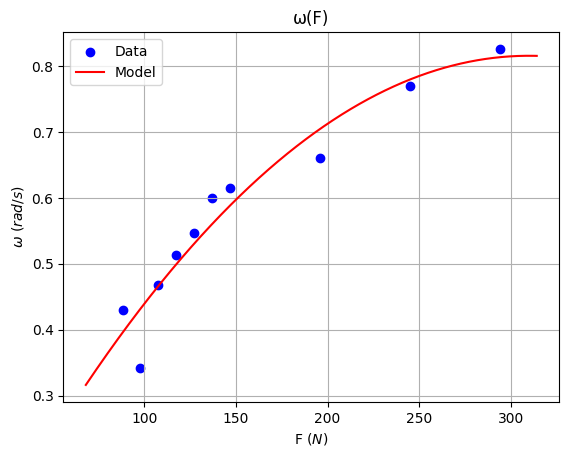

In [6]:
poly_model = LinearRegression()
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(F.reshape(-1,1))

poly_model.fit(poly_features, omega)
featurs_to_pred = poly.fit_transform(F_space)
poly_predict = poly_model.predict(featurs_to_pred)

plt.scatter(F,omega, label="Data", c="blue")
plt.plot(F_space, poly_predict, label="Model", c="red")
plt.title("ω(F)")
plt.xlabel("F ($N$)")
plt.ylabel("$\omega$ ($rad/s$)")
plt.legend()
plt.grid(True)
plt.show()

plotting α(F) function

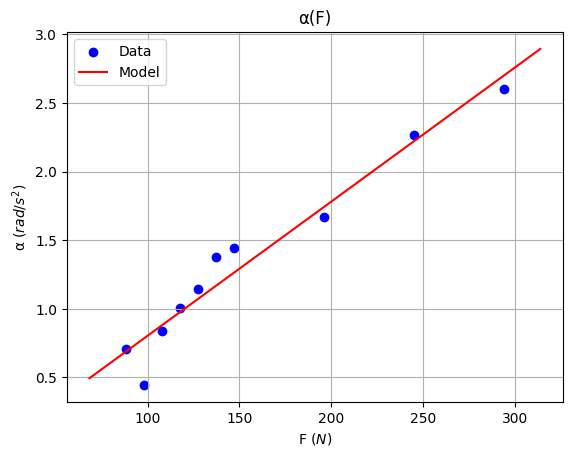

In [7]:
model = LinearRegression()
model.fit(F.reshape(-1,1), alpha.reshape(-1, 1))
lin_pred = model.predict(F_space)

plt.scatter(F,alpha, label="Data", c="blue")
plt.plot(F_space, lin_pred, label="Model", c="r")
plt.title("α(F)")
plt.xlabel("F ($N$)")
plt.ylabel("α ($rad/s^2$)")
plt.legend()
plt.grid(True)
plt.show()

#With Varing Radius

In [36]:
RAW_DATA_TAB_2345 = {
    "m=12":{
        "r=1.5": [4.772, 5.383, 6.059, 6.594, 7.263],
        "r=3": [2.831, 3.423, 3.929, 4.432, 5.122],
        "r=4.5": [2.507, 3.350, 3.666, 3.937, 4.267]
    },
    "m=18":{
        "r=1.5": [3.841, 4.192, 4.886, 5.802, 6.302],
        "r=3": [2.235, 2.794, 3.228, 3.601, 3.923],
        "r=4.5": [1.923, 2.317, 2.756, 3.184, 3.303]
    },
    "m=24":{
        "r=1.5": [3.262, 3.948, 4.472, 5.051, 5.838],
        "r=3": [2.073, 2.833, 3.213, 3.421, 3.748 ],
        "r=4.5": [1.701, 2.082, 2.370, 2.755, 2.847]
    },
    "m=30":{
        "r=1.5": [3.137, 3.738, 4.186, 4.658, 5.037],
        "r=3": [2.154, 2.918, 2.888, 3.183, 3.399],
        "r=4.5": [1.500, 1.768, 2.071, 2.304, 2.563]
    }
}

In [38]:
phi = np.array([60, 90, 120, 150, 180])*(np.pi/180)

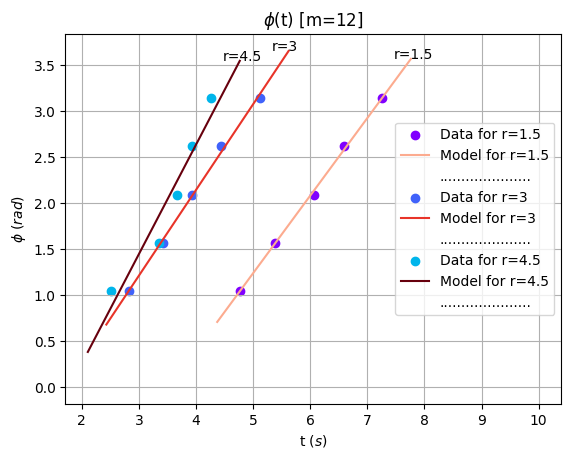

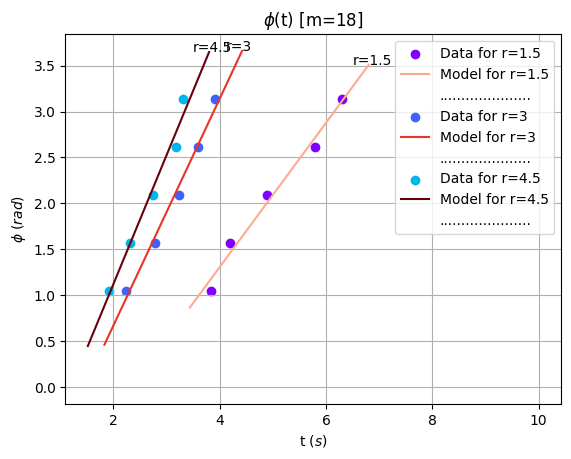

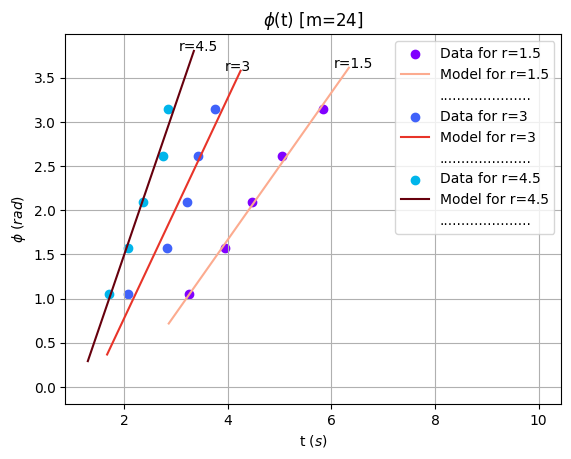

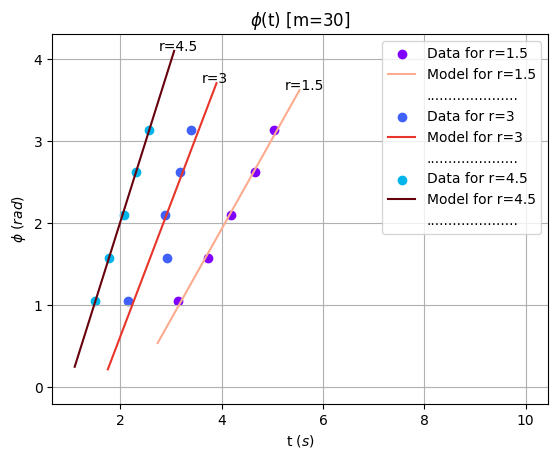

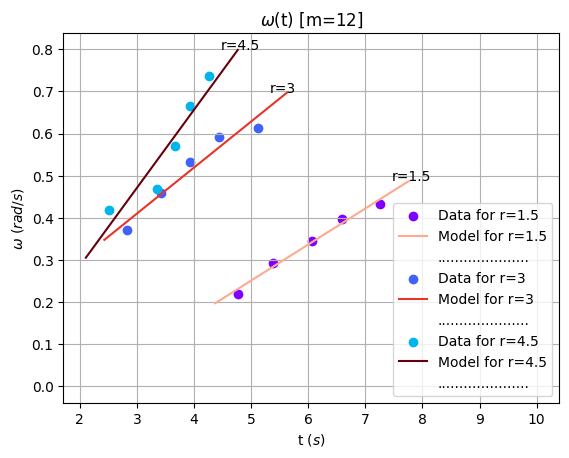

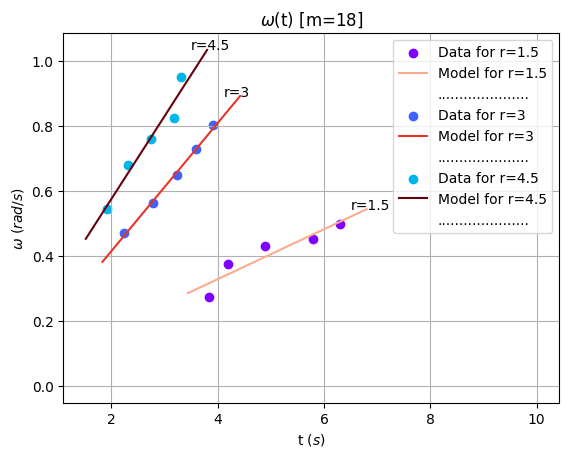

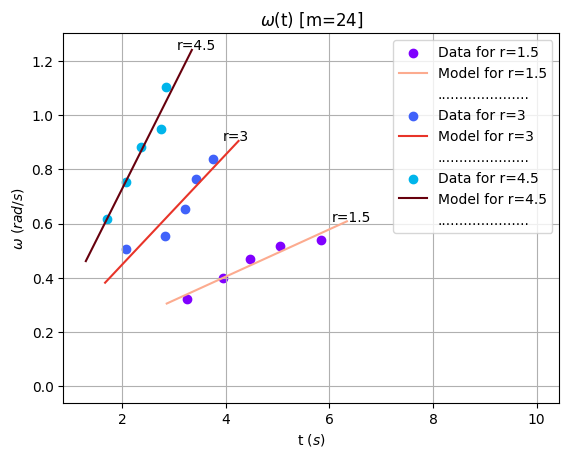

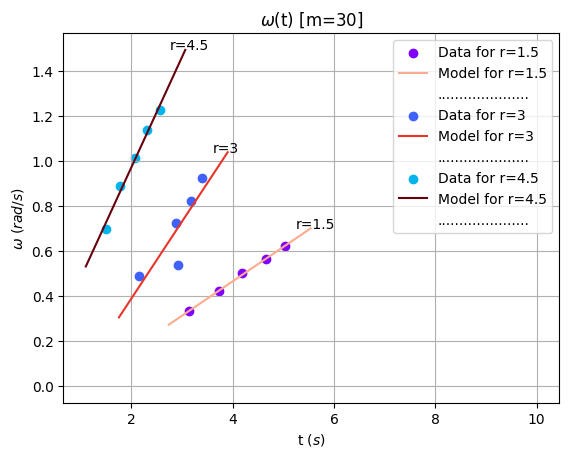

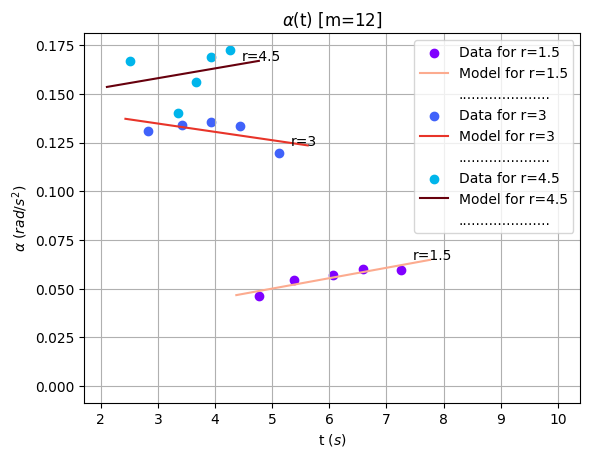

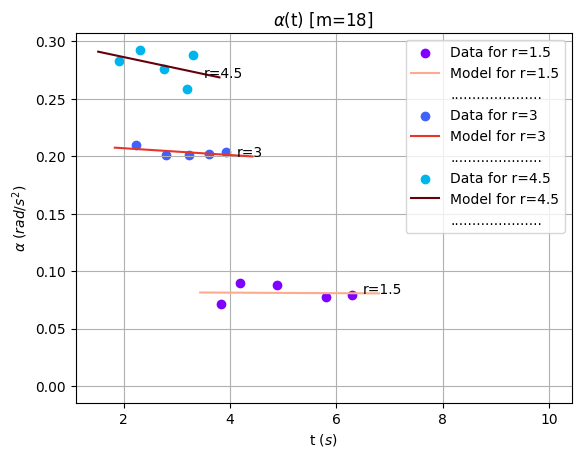

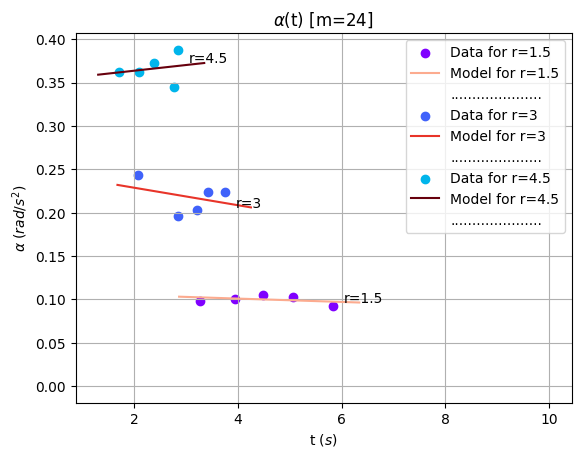

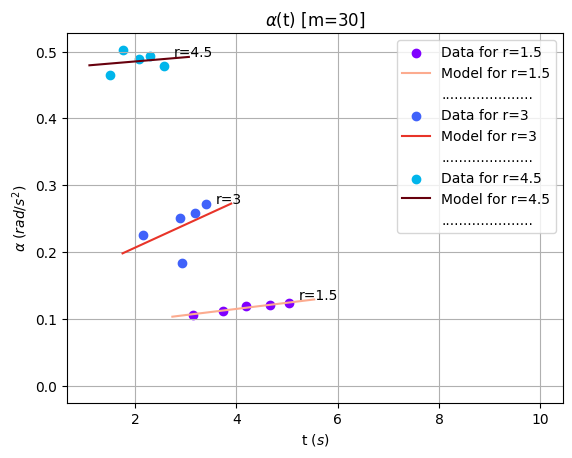

In [77]:

y_names = ["phi","omega", "alpha"]
for y_name in y_names:
    for m_i in RAW_DATA_TAB_2345:
        num_items = len(RAW_DATA_TAB_2345[m_i])   
        color = iter(plt.cm.rainbow(np.linspace(0,1,num_items*3)))
        
        color_reg = iter(plt.cm.Reds(np.linspace(0.3,1,num_items)))

        for r, t_i in RAW_DATA_TAB_2345[m_i].items(): # t_i : list
            c = next(color)
            t_i = np.array(t_i)
            model = LinearRegression()
            t_space = np.linspace(t_i[0]-0.4, t_i[-1]+0.5, 1000).reshape(-1, 1)
            y = phi/(t_i**2) if y_name == "alpha" else (phi/t_i if y_name == "omega" else phi)
            model.fit(t_i.reshape(-1,1), y.reshape(-1, 1))
            lin_pred = model.predict(t_space)

            plt.scatter(t_i,y, label=f"Data for {r}", color=c)
            plt.text(t_space[-1]-0.3, lin_pred[-1], f"{r}")
            c2 = next(color_reg)
            plt.plot(t_space, lin_pred, label=f"Model for {r}", color=c2)
            
            #seperator legend
            plt.plot([9,10], [0,0], label= ".....................", c="black", marker='', linestyle='None' )
            #plt.plot([9,10], [0,0], label= "-__________-", c="black",  marker='|', markersize=3, linestyle='None')

            plt.title(f"$\{y_name}$(t) [{m_i}]")
            plt.xlabel("t ($s$)")
            plt.ylabel(f"$\{y_name}$ ($rad{'/s^2' if y_name == 'alpha' else ('/s' if y_name == 'omega' else '')}$)")
            plt.grid(True)
            plt.legend()
        plt.show()